**Credit Card Fraud Detection Using Machine Learning**
**Author: Puram Pavan Adithya**
Domain: Data Science Internship
Credit card fraud is a major issue in the financial sector, leading to significant monetary losses for banks and customers. Detecting fraudulent transactions is challenging because fraud cases are very rare compared to normal transactions, making it an imbalanced classification problem.
The goal of this project is to build a machine learning model that can accurately identify fraudulent transactions based on various transaction features. This helps financial institutions take preventive actions and reduce fraud-related losses.
The objective of this project is to analyze transaction data and develop a predictive model that distinguishes between genuine and fraudulent transactions.
This system can assist banks in improving security measures and ensuring safer transactions for customers.

The dataset used in this project contains anonymized credit card transaction details. Due to privacy reasons, most features are transformed using PCA.
The dataset includes the following features:
Time
Amount
V1 to V28 (PCA transformed features)
The target variable is:
Class
0 → Normal Transaction
1 → Fraudulent Transaction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [4]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve


In [5]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In this step, all necessary libraries are imported. Pandas and NumPy are used for data handling, Matplotlib and Seaborn for visualization, and Scikit-learn for machine learning models and evaluation. SMOTE is used to handle class imbalance, and XGBoost is used as an advanced model.

In [6]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


The dataset is loaded using Pandas. The head() function displays the first few rows to understand the structure of the dataset.

In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49610 entries, 0 to 49609
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    49610 non-null  int64  
 1   V1      49610 non-null  float64
 2   V2      49610 non-null  float64
 3   V3      49610 non-null  float64
 4   V4      49609 non-null  float64
 5   V5      49609 non-null  float64
 6   V6      49609 non-null  float64
 7   V7      49609 non-null  float64
 8   V8      49609 non-null  float64
 9   V9      49609 non-null  float64
 10  V10     49609 non-null  float64
 11  V11     49609 non-null  float64
 12  V12     49609 non-null  float64
 13  V13     49609 non-null  float64
 14  V14     49609 non-null  float64
 15  V15     49609 non-null  float64
 16  V16     49609 non-null  float64
 17  V17     49609 non-null  float64
 18  V18     49609 non-null  float64
 19  V19     49609 non-null  float64
 20  V20     49609 non-null  float64
 21  V21     49609 non-null  float64
 22

This step provides information about data types, missing values, and statistical summary. It helps in understanding the dataset before preprocessing.

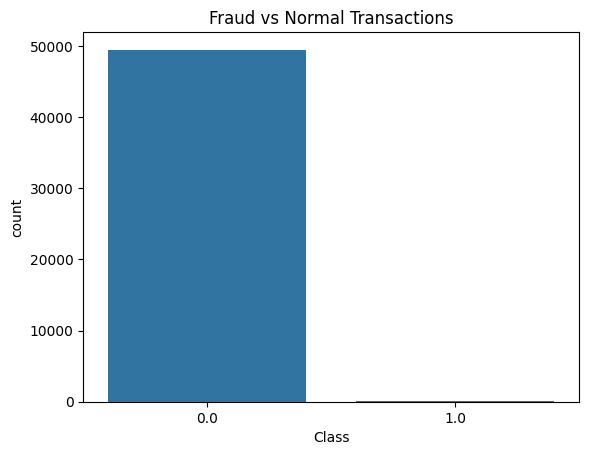

Class
0.0    49461
1.0      148
Name: count, dtype: int64


In [9]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

print(df['Class'].value_counts())

The above graph represents the distribution of fraudulent and normal transactions in the dataset. It is clearly observed that the number of normal transactions (Class 0) is significantly higher compared to fraudulent transactions (Class 1).
From the dataset, there are approximately 49,461 normal transactions and only 148 fraudulent transactions. This indicates a severe class imbalance problem, where the minority class (fraud cases) is very small compared to the majority class.
Due to this imbalance, machine learning models may become biased towards predicting normal transactions. Therefore, techniques such as SMOTE and class weighting are used to handle this imbalance and improve fraud detection performance.

In [10]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

Feature scaling is applied to normalize the 'Amount' and 'Time' features so that all values are on a similar scale. This improves model performance.

In [13]:
print(df['Class'].isnull().sum())

1


In [14]:
df = df.dropna()

In [15]:
print(df['Class'].isnull().sum())

0


In [16]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

The dataset is split into training and testing sets. The stratify parameter ensures that class distribution remains the same in both sets.

In [17]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

SMOTE (Synthetic Minority Oversampling Technique) is used to generate synthetic samples for the minority class (fraud cases), making the dataset balanced.

In [30]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [31]:
y_prob = xgb.predict_proba(X_test)[:,1]

threshold = 0.30
y_pred_xgb = (y_prob > threshold).astype(int)

In [32]:
print("\n===== XGBoost Model Performance =====\n")

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))


===== XGBoost Model Performance =====

XGBoost Accuracy: 0.9991937109453739
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9892
         1.0       0.84      0.90      0.87        30

    accuracy                           1.00      9922
   macro avg       0.92      0.95      0.94      9922
weighted avg       1.00      1.00      1.00      9922

[[9887    5]
 [   3   27]]


The XGBoost model achieved an accuracy of approximately 99.91%, indicating excellent overall performance. The classification report shows that the model performs extremely well in identifying normal transactions with perfect precision and recall.
For fraudulent transactions, the model achieved a precision of 0.84 and a recall of 0.90, which means it is able to correctly detect most fraud cases while maintaining a good balance between false positives and false negatives.
The confusion matrix further shows that 9887 normal transactions were correctly classified, while only 5 were misclassified. Additionally, out of 30 fraud cases, 27 were correctly detected and only 3 were missed.
These results demonstrate that XGBoost is highly effective in handling imbalanced data and provides strong fraud detection performance.

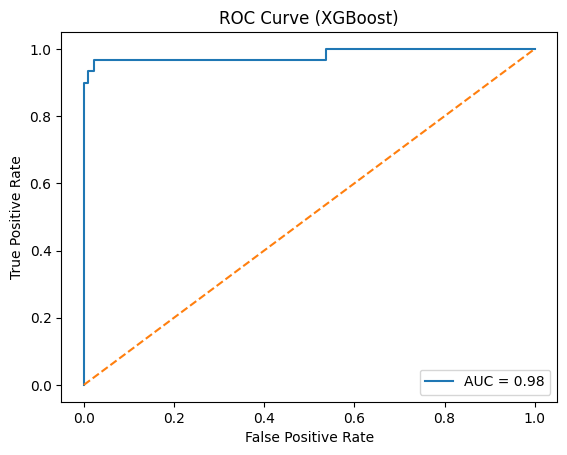

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve (XGBoost)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The ROC curve evaluates model performance by comparing true positive rate and false positive rate. A higher AUC value indicates better performance.

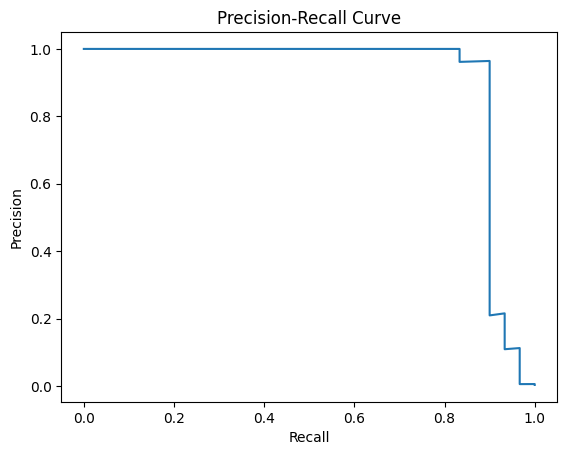

In [34]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Precision-Recall curve is especially useful for imbalanced datasets as it focuses on correctly identifying fraud cases.

In [35]:
threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))

[[9887    5]
 [   3   27]]


The threshold is reduced from 0.5 to 0.3 to increase the detection of fraud cases. This improves recall.

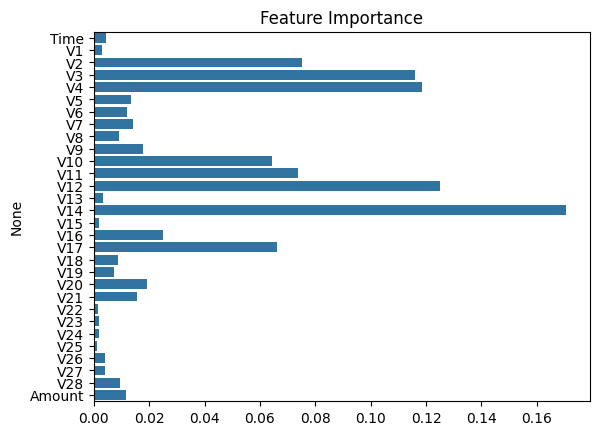

In [36]:
importances = rf.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

The feature importance graph shows the contribution of each feature in predicting fraudulent transactions. Features such as V14, V12, and V10 have higher importance scores, indicating that they play a significant role in identifying fraud cases. On the other hand, features like Time and Amount have lower importance, meaning they contribute less to the prediction. This helps in understanding which variables influence the model decisions the most.

**Conclusion:**

In this project, a machine learning-based Credit Card Fraud Detection system was developed using the XGBoost algorithm to identify fraudulent transactions in a highly imbalanced dataset. The data was preprocessed through feature scaling and splitting, and class imbalance was handled using SMOTE to improve the model’s ability to detect fraud cases.
The XGBoost model was trained to learn complex patterns in the transaction data and achieved very high accuracy along with strong recall for fraudulent transactions. This ensures that most fraud cases are correctly identified while maintaining a balance between false positives and false negatives.
The model was evaluated using performance metrics such as precision, recall, F1-score, confusion matrix, and ROC curve, which provide a more reliable evaluation compared to accuracy alone. Feature importance analysis was also performed to understand the contribution of different features in fraud detection.
Overall, the project demonstrates that XGBoost is highly effective for fraud detection in imbalanced datasets and can be used to build reliable and efficient fraud detection systems. In the future, the model can be further improved by deploying it in real-time systems and integrating advanced techniques.